# Titanic Survival Prediction using Logistic Regression

## NeuroFive ML Track - Week 2 Task 1

**Author:** Muhammad Fahad

---

## Objective

The objective of this project is to build a machine learning classification model that predicts whether a passenger survived the Titanic disaster. The project includes data preprocessing, feature encoding, model training, prediction, and evaluation using Logistic Regression.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset

df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Dataset Shape

df.shape

(891, 12)

In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Missing Values

df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
# Fill Missing Values

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Cabin"] = df["Cabin"].fillna("Unknown")

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Feature Selection

Machine learning models require two types of data:

- **Features (X):** Input variables used to make predictions.
- **Target (y):** Output variable that the model predicts.

In this project, the target variable is **Survived**, while the remaining selected columns are used as features.

In [8]:
# Select useful columns

df = df[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "Survived"
]]

df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


## Feature Encoding

Machine learning algorithms cannot work directly with text values.

Categorical features such as **Sex** and **Embarked** are converted into numerical values using one-hot encoding.

In [10]:
# Convert categorical columns into numerical columns

df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

df.head()

,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


In [11]:
# Features

X = df.drop("Survived", axis=1)

# Target

y = df["Survived"]

## Splitting Features and Target

The dataset is divided into:

- **X:** Input features
- **y:** Target variable (Survived)

## Train-Test Split

The dataset is divided into training and testing sets.

- **Training Set:** Used to train the model.
- **Testing Set:** Used to evaluate the model on unseen data.

The data is split into 80% training and 20% testing.

In [12]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (712, 8)
Testing Data: (179, 8)


## Model Training

A Logistic Regression model is trained using the training dataset to predict passenger survival.

In [13]:
# Create the model

model = LogisticRegression(max_iter=1000)

# Train the model

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
# Predict survival

y_pred = model.predict(X_test)

## Model Evaluation

After training the Logistic Regression model, we evaluate its performance using:

- Accuracy Score
- Confusion Matrix

These metrics help us understand how well the model predicts passenger survival.

In [16]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [17]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[90 15]
 [19 55]]


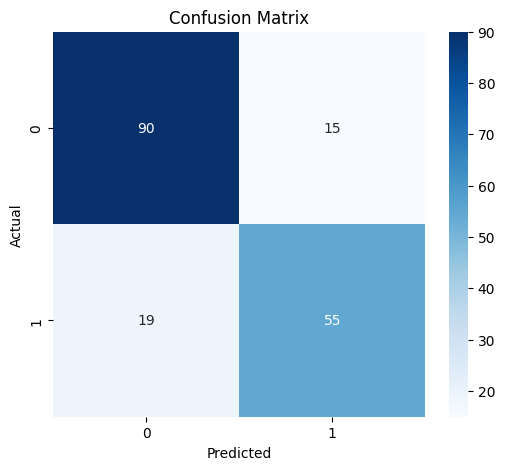

In [18]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Confusion Matrix Analysis

The confusion matrix shows how many predictions were correct and incorrect.

- The model correctly predicted **90** passengers who did not survive.
- The model correctly predicted **55** passengers who survived.
- It incorrectly predicted **15** passengers as survived when they actually did not survive.
- It incorrectly predicted **19** passengers as not survived when they actually survived.

Overall, the model achieved an accuracy of approximately **81%**, which indicates that it performed well on the test dataset.

# Conclusion

In this project, I built my first machine learning classification model using Logistic Regression.

The dataset was cleaned by handling missing values and converting categorical features into numerical values using one-hot encoding.

The data was then split into training and testing sets, and a Logistic Regression model was trained to predict passenger survival.

The model achieved an accuracy of **81%**, showing that it performed well in predicting whether a passenger survived or not.

This project helped me understand the complete machine learning workflow, from data preprocessing to model evaluation.